# Chapter 8: Using Convolutions to generalize

Data prep:

In [5]:
from torchvision import datasets, transforms
data_path = '../data/cifar10/'

# Instantiates a dataset for the training data; TorchVision downloads the data if it is not present.
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

# With train=False, we get a dataset for the validation data, again downloading as necessary
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [6]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']

cifar2 = [(img, label_map[label])
          for img, label in cifar10
          if label in [0, 2]]

cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8628641..2.029448].


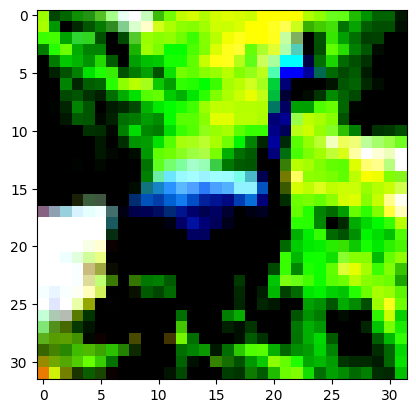

In [7]:
from matplotlib import pyplot as plt
img, _ = cifar2[0]
plt.imshow(img.permute(1, 2, 0))
plt.show()

### Build the model:

In [8]:
import torch.nn as nn

model = nn.Sequential(
nn.Conv2d(3, 16, kernel_size=3, padding=1),
nn.Tanh(),
nn.MaxPool2d(2),
nn.Conv2d(16, 8, kernel_size=3, padding=1),
nn.Tanh(),
nn.MaxPool2d(2),
# ...
)

The first convolution takes us from 3 RGB channels to 16, thereby giving the network a chance to generate 16 independent features that operate to (hopefully) discriminate low-level features of birds and airplanes. Then we apply the Tanh activation
function.

The resulting 16-channel 32 × 32 image is pooled to a 16-channel 16 × 16 image by the
first MaxPool2d. At this point, the downsampled image undergoes another convolution
that generates an 8-channel 16 × 16 output. With any luck, this output will consist of
higher-level features. Again, we apply a Tanh activation and then pool to an 8-channel
8 × 8 output.

 Where does this end? After the input image has been reduced to a set of 8 × 8 features, we expect to be able to output some probabilities from the network that we can
feed to our negative log likelihood. However, probabilities are a pair of numbers in a
1D vector (one for airplane, one for bird), but here we’re still dealing with multichannel 2D features.

 Thinking back to the beginning of this chapter, we already know what we need to
do: turn the 8-channel 8 × 8 image into a 1D vector and complete our network with a
set of fully connected layers:

In [9]:
model = nn.Sequential(
nn.Conv2d(3, 16, kernel_size=3, padding=1),
nn.Tanh(),
nn.MaxPool2d(2),
nn.Conv2d(16, 8, kernel_size=3, padding=1),
nn.Tanh(),
nn.MaxPool2d(2),
# something is missing here
nn.Linear(8 * 8 * 8, 32),
nn.Tanh(),
nn.Linear(32, 2))

Ignore the “something missing” comment for a minute. Let’s first notice that the
size of the linear layer is dependent on the expected size of the output of MaxPool2d:
8 × 8 × 8 = 512. Let’s count the number of parameters for this small model:

In [10]:
numel_list = [p.numel() for p in model.parameters()]
sum(numel_list), numel_list

(18090, [432, 16, 1152, 8, 16384, 32, 64, 2])

That’s very reasonable for a limited dataset of such small images. To increase the
capacity of the model, we could increase the number of output channels for the convolution layers (i.e., the number of features each convolution layer generates), which
would lead the linear layer to increase its size as well.

 We put the “warning” note in the code for a reason. The model has zero chance of
running without complaining:

In [11]:
model(img.unsqueeze(0))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8 and 512x32)

Admittedly, the error message is a bit obscure, but not too much so. We find references to linear in the traceback: looking back at the model, we see that the only module that has to have a 512 × 32 tensor is nn.Linear(512, 32), the first linear module
after the last convolution block.

 **What’s missing there is the reshaping step from an 8-channel 8 × 8 image to a
512-element, 1D vector (1D if we ignore the batch dimension, that is). This could
be achieved by calling view on the output of the last nn.MaxPool2d, but, unfortunately, we don’t have any explicit visibility of the output of each module when we
use nn.Sequential**. We’ll see how to fix this problem in the next section.


### Sub-Classing

To create our network, we’ll instantiate all the individual layer modules (nn.Conv2d, nn.Linear, etc.) in the constructor
and then specify how data flows through these modules in the forward method:

Without function API:

In [12]:
# In[27]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) #This reshape is what we were missing earlier.
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

Simplified with Function API:

In [13]:
import torch.nn.functional as F
import torch

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [14]:
model = Net()
model(img.unsqueeze(0))

tensor([[ 0.2007, -0.1765]], grad_fn=<AddmmBackward0>)

We got two numbers! Information flows correctly. We might not realize it right now,
but in more complex models, getting the size of the first linear layer right is sometimes a source of frustration. We’ve heard stories of famous practitioners putting in
arbitrary numbers and then relying on error messages from PyTorch to backtrack the
correct sizes for their linear layers.

### The training loop:

In [15]:
# In[31]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    # Our loop over the epochs, numbered from 1 to n_epochs rather than starting at 0
    for epoch in range(1, n_epochs + 1):
        start_time = datetime.datetime.now()
        loss_train = 0.0
        # Loops over our dataset in the batches the data loader creates for us
        for imgs, labels in train_loader:

            # Feeds a batch through our mode...
            outputs = model(imgs)

            # ... and computes the loss we wish to minimize
            loss = loss_fn(outputs, labels)

            # After getting rid of the gradients from the last round …
            optimizer.zero_grad()

            # … performs the backward step. That is, we compute the gradients of all
            # parameters we want the network to learn.
            loss.backward()

            # Updates the model using the gradients we just computed
            optimizer.step()

            # Sums the losses we saw over the epoch. Recall that it is important to transform
            # the loss to a Python number with .item(), to escape the gradients.
            loss_train += loss.item()

        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {:.6f}, Time {:.2f}s'.format(
            datetime.datetime.now(), epoch,
            # Divides by the length of the training data loader to get the average loss per batch.
            # This is a much more intuitive measure than the sum.
            loss_train / len(train_loader), epoch_duration))

In [17]:
import torch.optim as optim

# The DataLoader batches up the examples of our cifar2 dataset. Shuffling randomizes the
# order of the examples from the dataset.
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
shuffle=True)

# Instantiates our network …
model = Net()

# … the stochastic gradient descent optimizer we have been working with …
optimizer = optim.SGD(model.parameters(), lr=1e-2) #
loss_fn = nn.CrossEntropyLoss() #
training_loop(
n_epochs = 100,
optimizer = optimizer,
model = model,
loss_fn = loss_fn,
train_loader = train_loader,
)

2026-09-08 16:37:42.796328 Epoch 1, Training loss 0.550143, Time 1.51s
2026-09-08 16:38:07.951167 Epoch 10, Training loss 0.335397, Time 2.82s
2026-09-08 16:38:27.105007 Epoch 20, Training loss 0.293881, Time 1.58s
2026-09-08 16:38:49.814035 Epoch 30, Training loss 0.264189, Time 2.94s
2026-09-08 16:39:09.296079 Epoch 40, Training loss 0.239244, Time 1.33s
2026-09-08 16:39:37.656642 Epoch 50, Training loss 0.220834, Time 2.87s
2026-09-08 16:40:06.838386 Epoch 60, Training loss 0.206644, Time 3.09s
2026-09-08 16:40:26.047867 Epoch 70, Training loss 0.190188, Time 1.41s
2026-09-08 16:40:38.490089 Epoch 80, Training loss 0.173294, Time 1.25s
2026-09-08 16:40:51.909870 Epoch 90, Training loss 0.160326, Time 1.26s
2026-09-08 16:41:16.878703 Epoch 100, Training loss 0.146929, Time 2.73s



###  Measuring accuracy
To have a measure that is more interpretable than the loss, we can take a look at our
accuracy on the training and validation datasets. We use the same code as in chapter 7:

In [18]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
shuffle=False)

def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
        # We do not want gradients here, as we will not want to update the parameters.
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)

                 # Gives us the index of the highest value as output
                _, predicted = torch.max(outputs, dim=1)

                # Counts the number of examples, so the total is increased by the batch size
                total += labels.shape[0]

                # Comparing the predicted class that had the maximum probability and the
                # ground-truth labels, we first get a Boolean array. Taking the sum gives
                # the number of items in the batch where the prediction and ground truth agree.
                correct += int((predicted == labels).sum())
        print("Accuracy {}: {:.2f}".format(name , correct / total))

validate(model, train_loader, val_loader)

Accuracy train: 0.94
Accuracy val: 0.89


### Saving the Model:

In [19]:
torch.save(model.state_dict(), "../models/" + 'birds_vs_airplanes.pt')

In [20]:
# reload the model
loaded_model = Net()
loaded_model.load_state_dict(torch.load("../models/"
+ 'birds_vs_airplanes.pt'))

<All keys matched successfully>

### Training on the GPU:

In [21]:
model_a = Net()
model_b = model_a.to("cuda")
print(model_a is model_b)

tensor_a = torch.rand(1)
tensor_b = tensor_a.to("cuda")
print(tensor_a is tensor_b)

True
False


In [22]:
device = (torch.device('cuda')

if torch.cuda.is_available()
else torch.device('cpu'))
print(f"Training on device {device}.")

Training on device cuda.


In [23]:
import datetime

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epochs + 1):
        start_time = datetime.datetime.now()
        loss_train = 0.0
        for imgs, labels in train_loader:
            # Move the tensors to the GPU if we are on the GPU.
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)

            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()

        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {:.6f}, Time {:.2f}s'.format(
            datetime.datetime.now(), epoch,
            loss_train / len(train_loader), epoch_duration))

In [24]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
shuffle=True)
model = Net().to(device=device)

optimizer = optim.SGD(model.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()
training_loop(
n_epochs = 100,
optimizer = optimizer,
model = model,
loss_fn = loss_fn,
train_loader = train_loader,
)

2026-09-08 17:12:12.834362 Epoch 1, Training loss 0.570442, Time 1.72s
2026-09-08 17:12:17.350477 Epoch 10, Training loss 0.346859, Time 0.49s
2026-09-08 17:12:22.458860 Epoch 20, Training loss 0.301191, Time 0.48s
2026-09-08 17:12:27.557382 Epoch 30, Training loss 0.276665, Time 0.50s
2026-09-08 17:12:34.041744 Epoch 40, Training loss 0.259315, Time 0.66s
2026-09-08 17:12:39.485350 Epoch 50, Training loss 0.235703, Time 0.58s
2026-09-08 17:12:46.302521 Epoch 60, Training loss 0.218975, Time 0.55s
2026-09-08 17:12:52.328658 Epoch 70, Training loss 0.205255, Time 0.52s
2026-09-08 17:12:57.494576 Epoch 80, Training loss 0.188605, Time 0.52s
2026-09-08 17:13:10.725122 Epoch 90, Training loss 0.177544, Time 1.34s
2026-09-08 17:13:18.974835 Epoch 100, Training loss 0.163598, Time 0.53s


Even for our small network here, we see a sizable increase in speed. The advantage of
computing on GPUs is more visible for larger models.

 There is a slight complication when loading network weights: PyTorch will attempt
to load the weight to the same device it was saved from—that is, weights on the GPU
will be restored to the GPU. As we don’t know whether we want the same device, we
have two options: we could move the network to the CPU before saving it, or move it
back after restoring. It is a bit more concise to instruct PyTorch to override the device
information when loading weights. This is done by passing the map_location keyword
argument to torch.load:

In [ ]:
loaded_model = Net().to(device=device)
loaded_model.load_state_dict(torch.load("../models/"
+ 'birds_vs_airplanes.pt',
map_location=device))

### Adding memory capacity: Width

Given our feed-forward architecture, there are a couple of dimensions we’d likely
want to explore before getting into further complications. The first dimension is the
width of the network: the number of neurons per layer, or channels per convolution.
We can make a model wider very easily in PyTorch. We just specify a larger number of
output channels in the first convolution and increase the subsequent layers accordingly, taking care to change the forward function to reflect the fact that we’ll now have
a longer vector once we switch to fully connected layers:

In [25]:
class NetWidth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
        padding=1)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1,8*8* self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [26]:
sum(p.numel() for p in model.parameters())

18090

### Regularization: L2 Manual Implementation for illustrative purposes only.

In [ ]:
def training_loop_l2reg(n_epochs, optimizer, model, loss_fn,
train_loader):
    for epoch in range(1, n_epochs + 1):
        loss_train = 0.0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)

            l2_lambda = 0.001
            l2_norm = sum(p.pow(2.0).sum() for p in model.parameters())
            loss = loss + l2_lambda * l2_norm

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_train += loss.item()
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
            datetime.datetime.now(), epoch,
            loss_train / len(train_loader)))

However, the SGD optimizer in PyTorch already has a weight_decay parameter that
corresponds to 2 * lambda, and it directly performs weight decay during the update as
described previously. It is fully equivalent to adding the L2 norm of weights to the loss,
without the need for accumulating terms in the loss and involving autograd, so usually
we should defer to using the Pytorch weight_decay parameter to reduce the risk of any
implementation mistakes.

Dropout:

In [ ]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
        padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1,8*8* self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

Note that dropout is normally active during training, while during the evaluation of a
trained model in production, dropout is bypassed or, equivalently, assigned a probability equal to zero. This is controlled through the train property of the Dropout module. Recall that PyTorch lets us switch between the two modalities by calling

model.train()

or

model.eval()

on any nn.Module subclass. The call will be automatically replicated on the submodules so that if Dropout is among them, it will behave accordingly in subsequent forward
and backward passes. Not putting the model in the eval mode during inference can be
a silent failure that will impair the model’s performance.

Batch normalization:

In [ ]:
# In[50]:
class NetBatchNorm(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_batchnorm = nn.BatchNorm2d(num_features=n_chans1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
        padding=1)
        self.conv2_batchnorm = nn.BatchNorm2d(num_features=n_chans1 // 2)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.conv1_batchnorm(self.conv1(x))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = self.conv2_batchnorm(self.conv2(out))
        out = F.max_pool2d(torch.tanh(out), 2)
        out = out.view(-1,8*8* self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

Just as for dropout, batch normalization needs to behave differently during training
and inference. In fact, at inference time, we want to avoid having the output for a specific input depend on the statistics of the other inputs we’re presenting to the model.

As such, we need a way to still normalize, but this time, fixing the normalization
parameters once and for all.
 As minibatches are processed, in addition to estimating the mean and standard
deviation for the current minibatch, PyTorch also updates the running estimates for
the mean and standard deviation that are representative of the whole dataset, as an
approximation. This way, when the user specifies
model.eval()
and the model contains a batch normalization module, the running estimates are frozen and used for normalization. To unfreeze running estimates and return to using
the minibatch statistics, we call model.train(), just as we did for dropout.

In [ ]:
# In[52]:
class NetDepth(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
        padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
        kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = F.max_pool2d(torch.relu(self.conv3(out)), 2)
        out = out.view(-1,4*4* self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out


In [ ]:
class NetRes(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
        padding=1)
        self.conv3 = nn.Conv2d(n_chans1 // 2, n_chans1 // 2,
        kernel_size=3, padding=1)
        self.fc1 = nn.Linear(4 * 4 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)

        # Residual connection
        out1 = out
        out = F.max_pool2d(torch.relu(self.conv3(out)) + out1, 2)

        out = out.view(-1,4*4* self.n_chans1 // 2)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

BUILDING VERY DEEP MODELS IN PYTORCH
We talked about exceeding 100 layers in a convolutional neural network. How can we
build that network in PyTorch without losing our minds in the process? The standard
strategy is to define a building block, such as a (Conv2d, ReLU, Conv2d) + skip connection block, and then build the network dynamically in a for loop. Let’s see it done
in practice. We will create the network depicted in figure 8.15.
 We first create a module subclass whose sole job is to provide the computation for
one block—that is, one group of convolutions, activation, and skip connection:

In [27]:
class ResBlock(nn.Module):
    def __init__(self, n_chans):
        super(ResBlock, self).__init__()
        self.conv = nn.Conv2d(n_chans, n_chans, kernel_size=3,
        padding=1, bias=False)
        self.batch_norm = nn.BatchNorm2d(num_features=n_chans)
        # Uses custom initializations. kaiming_normal_initializes with normal random elements with
        # standard deviation as computed in the ResNet paper
        # (https://arxiv.org/abs/1512.03385). The batch norm is initialized to produce output
        # distributions that initially have 0 mean and 0.5 variance.
        torch.nn.init.kaiming_normal_(self.conv.weight,
        nonlinearity='relu')
        torch.nn.init.constant_(self.batch_norm.weight, 0.5)
        torch.nn.init.zeros_(self.batch_norm.bias)

    def forward(self, x):
        out = self.conv(x)
        out = self.batch_norm(out)
        out = torch.relu(out)
        return out + x

In [28]:
class NetResDeep(nn.Module):
    def __init__(self, n_chans1=32, n_blocks=100):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.resblocks = nn.Sequential(
        *(n_blocks * [ResBlock(n_chans=n_chans1)]))
        self.fc1 = nn.Linear(8 * 8 * n_chans1, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = self.resblocks(out)
        out = F.max_pool2d(out, 2)
        out = out.view(-1,8*8* self.n_chans1)
        out = torch.relu(self.fc1(out))
        out = self.fc2(out)
        return out

This demonstrates how we can create a larger network using our ResBlocks.